In [26]:
import matplotlib.pyplot as plt
import csv
from collections import defaultdict
def get_APD(lib, dt,APD_percentage = 0.3): # lib is 2D array, each row is a time series of one pixel
    def linear_interpolation(y0,y1,x0,x1,x):
        
        return (y0 * (x1-x) + y1 * (x-x0)) / (x1-x0)
    APD = defaultdict(list)
    for key in lib:

        APD[key] = []

        APD_value = 0
        start_apd = False
        for j in range(len(lib[key])):


            if start_apd == False and lib[key][j] > APD_percentage:
                start_apd = True
                if j == 0:
                    APD_start_error = 0
                else:
                    APD_start_error = linear_interpolation(1,0,lib[key][j],lib[key][j-1],APD_percentage)
                    APD_start_error = 1 - APD_start_error
                
            if start_apd == True and lib[key][j] <= APD_percentage: 
                start_apd = False
                APD_end_error = linear_interpolation(0,-1,lib[key][j],lib[key][j-1],APD_percentage)
                
                APD_value += (APD_start_error + APD_end_error) * dt                
                APD[key].append(APD_value)
                APD_value = 0
                APD_start_error = -100
                APD_end_error = -100
            if start_apd == True:
                APD_value += dt
    return APD

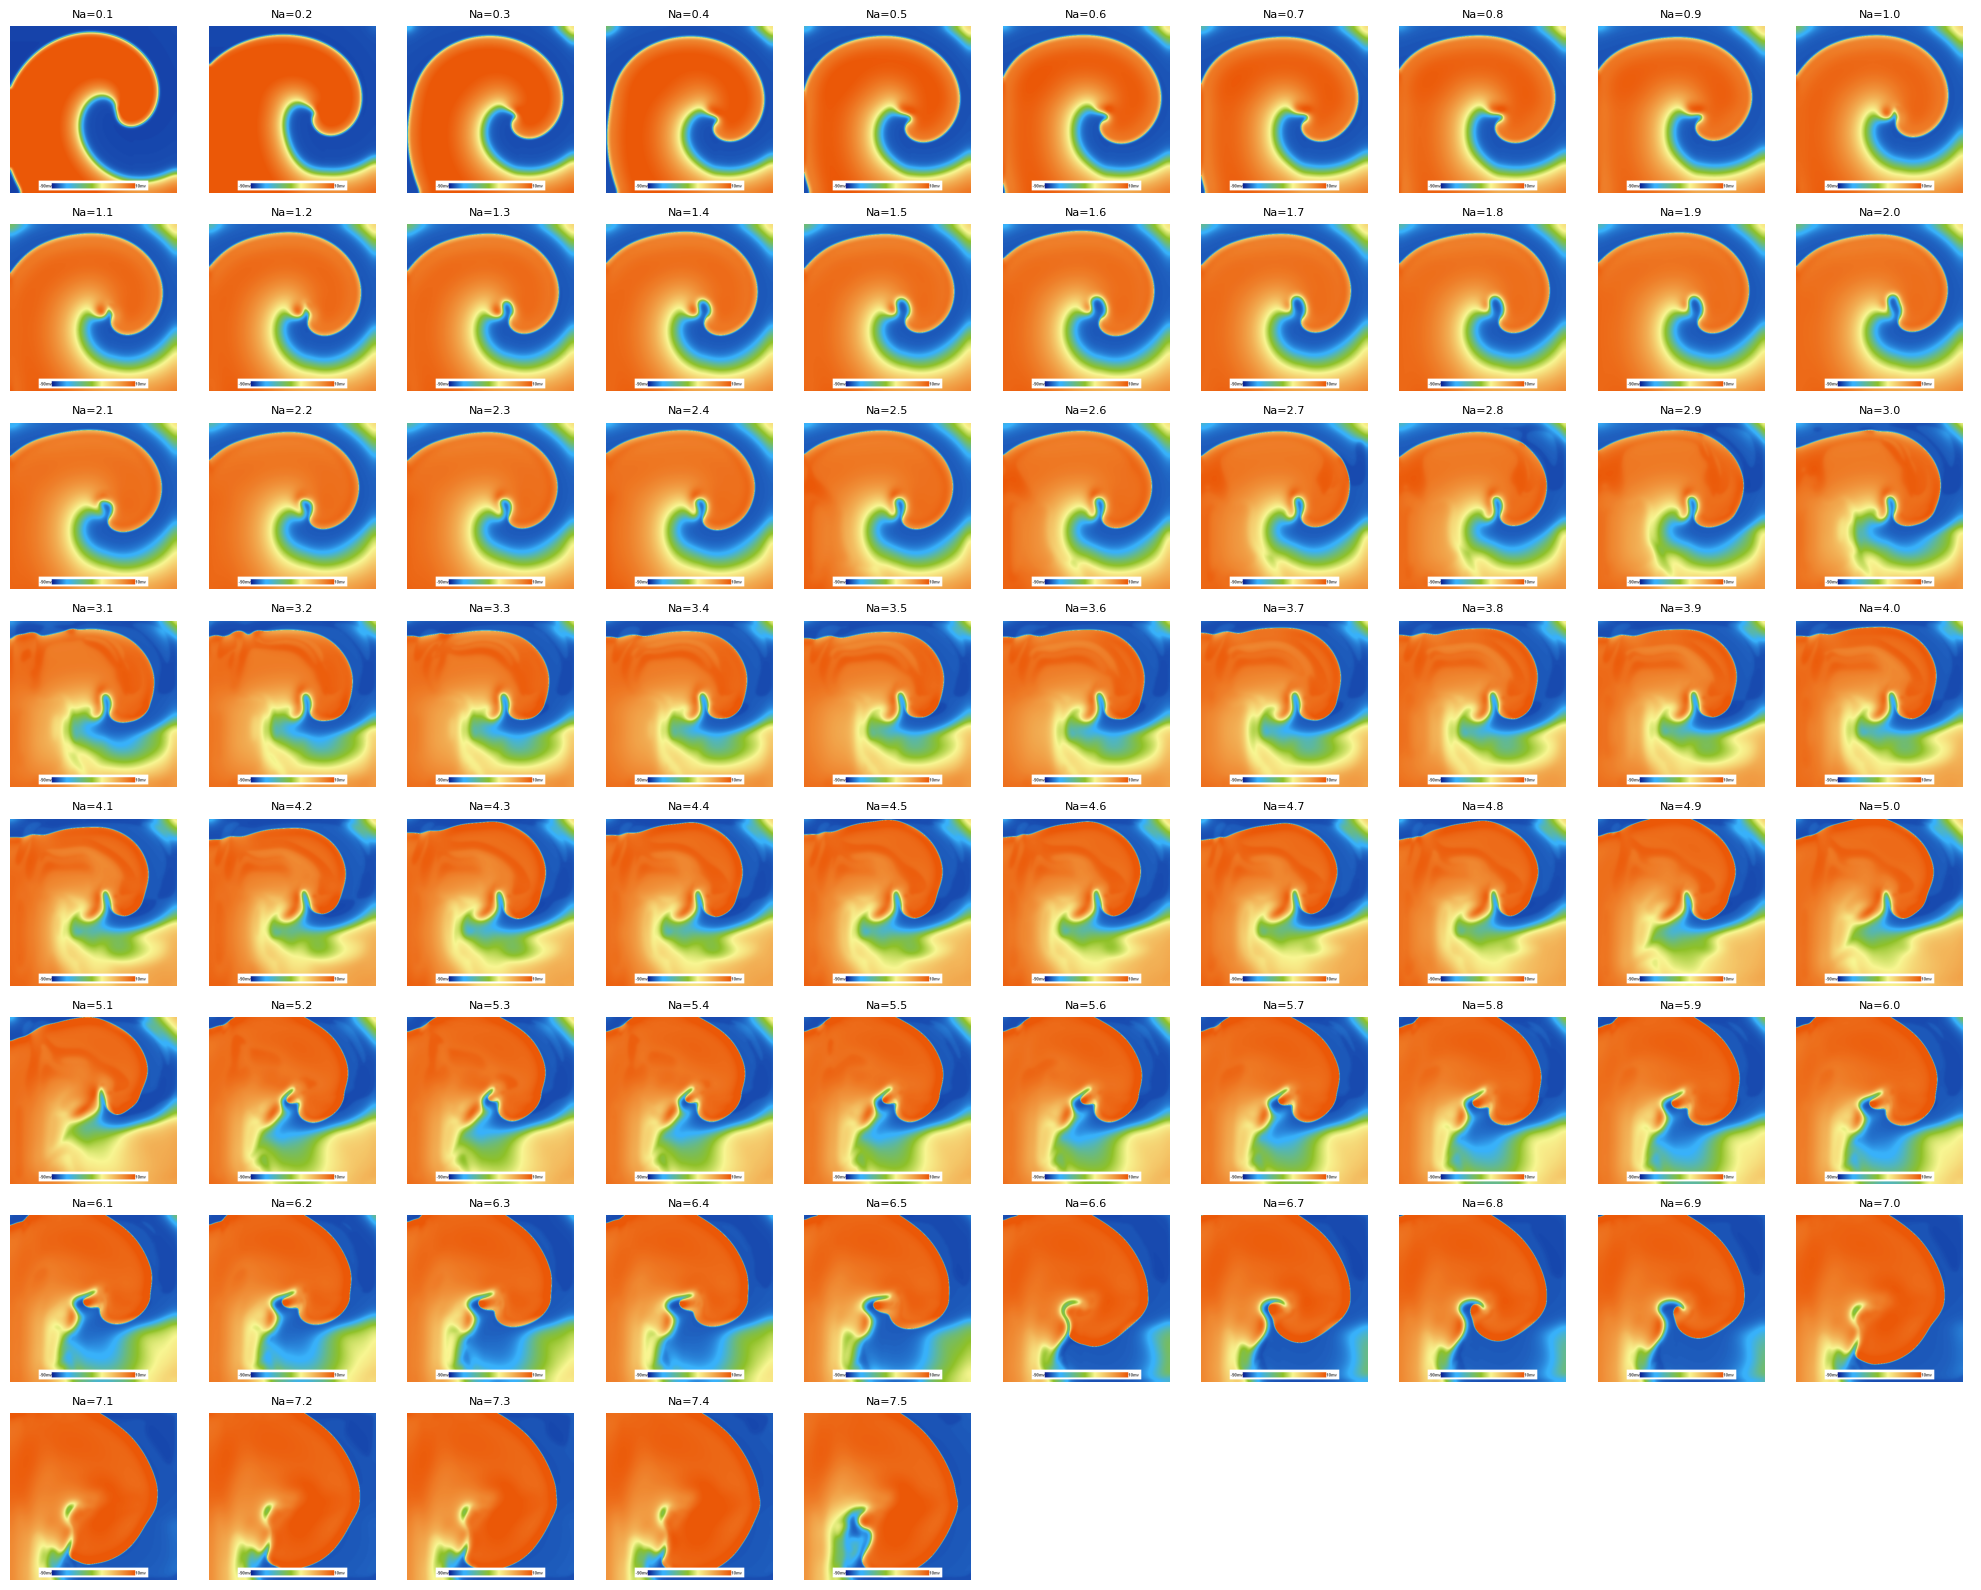

In [47]:
# Create an 8x10 grid (80 slots for 75 images)
fig, axs = plt.subplots(8, 10, figsize=(20, 16))

# Flatten the grid to a single list for easy looping
for i, ax in enumerate(axs.flat):
    if i < 75:
        try:
            # Generate path for Na = 0.1 to 7.5
            path = rf"C:\Users\xan37\Downloads\C_Na_{(i+1)/10:.2f}_time_1000_0.8_0.8.png"
            img = plt.imread(path)
            
            # Show image with your specific coordinate extent
            ax.imshow(img, extent=[0, img.shape[1], 0, img.shape[0]])
            ax.set_title(f"Na={(i+1)/10:.1f}", fontsize=8)
        except: pass
    
    ax.axis('off') # Hide axis lines for cleanness

plt.tight_layout()
plt.savefig("TNNP_Na_Variation.png", dpi=300)

In [ ]:
# read csv
csv_file = r"C:\Users\xan37\Downloads\result_Na.csv"
step = None
voltage = {}
with open(csv_file, 'r') as file:
    reader = csv.reader(file, delimiter=',')
    cur_v = []
    for row in reader:
        # if row start with step
        if row[0].startswith("step"):
            # step = step_{step}
            step = float(row[0].split('_')[1])
            continue
        elif len(row) == 1:
            key = float(row[0])
            voltage[key] = cur_v
            continue
        cur_v = [float(v) for v in row if v]
# APD = get_APD(voltage, dt=step, APD_percentage=0.3)



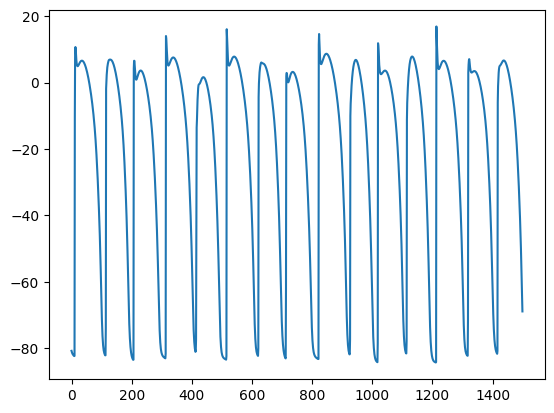

In [58]:
plt.plot(voltage[5.1])